## **BIA 810 - Healthcare Advanced Analytics - Final Project**

### **Problem Statement**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
The anesthesia drug market is a segment of the pharmaceutical industry that focuses on the development,
production, and distribution of medications used to induce and maintain anesthesia during medical
procedures and surgeries. The market for anesthesia drugs encompasses a wide range of pharmaceutical
products, including general anesthetics, local anesthetics, and adjunctive drugs that support the
anesthesia process. The demand for these drugs is closely tied to the healthcare industry, as the number
of surgical procedures, including both routine and complex surgeries, continues to grow worldwide.
Factors such as an aging population, increased healthcare access, and advancements in medical
technology contribute to the expansion of the anesthesia drug market.<br><br>
You are a Healthcare Commercial Analytics leader working for anesthesia drugs portfolio at a big pharma
company. As an analytics leader, understanding market dynamics and making evidence-based decisions
are crucial for the success of the business. Your company has a market leading brand <span style="background-color:#7FA7C9; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 1- <strong>J1885</strong></span> in the
anesthesia portfolio. Your company also has recently launched a variant of the same brand <span style="background-color:#163A5F; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 2- <strong>J2250</strong></span> in
the market which is supposed to cannibalize your leading brand. (Market cannibalization is a loss in sales
caused by a company's introduction of a new product that displaces one of its own older products in the
market. The cannibalization of existing products need not necessarily lead to an increase in the company's
overall market share, but at least the sales growth for the new product should be at the expense of the
drop in sales of the old product.)<br><br>
However, the expected cannibalization is not happening in the market. It appears that instead of your
new product capturing the dropping sales of your old product, one of your competitors <span style="background-color:#FA7F3C; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 3- <strong>J3010</strong></span> is
rapidly gaining market share, leaving your new product <span style="background-color:#163A5F; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 2- <strong>J2250</strong></span> to lose its expected market share.<br><br>
Though <span style="background-color:#FA7F3C; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 3- <strong>J3010</strong></span> is the primary competitor brand, this product absorbing the market share is also a threat for your brands. So, consider <span style="background-color:#F5C06A; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 4- <strong>J2704</strong></span> as a competitor brand as well.
</div>

In [1]:
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_columns', None)

### **0. Analytics-Ready Dataset Preparation**

#### 0.1.1 Organize Medicare Claims Data

In [3]:
claims_1_raw =  pd.read_csv("input_datasets/Medicare_Claims_data_part_1.csv")
claims_1_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1272380,10791,1.316539e+09,11/8/2016,11/7/2016,S81811D,154.73,11182.21567,11.0,G8996,-0.04,12.0,Z951,NaN,NaN,NaN,NaN
1,631196,10107,1.033202e+09,7/21/2016,7/12/2016,S0083XA,NaN,NaN,1.0,76700,2.57,NaN,I10,NaN,NaN,8.86,69
2,1548564,10412,1.880497e+09,7/14/2018,5/20/2018,R918,NaN,NaN,1.0,C1751,53.81,NaN,I10,NaN,NaN,86.40,30
3,1427731,10934,1.655569e+09,6/19/2016,7/15/2016,I2119,705.89,20750.00517,17.0,85378,-5.91,7.0,M25552,NaN,NaN,NaN,NaN
4,428779,965,1.644309e+09,3/21/2017,8/10/2018,C4490,2884.15,18437.66432,5.0,80061,2.62,6.0,Z9049,NaN,NaN,NaN,NaN


In [4]:
claims_1 = claims_1_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_1

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1272380,11/8/2016,10791,1.316539e+09,Z951,G8996
1,631196,7/21/2016,10107,1.033202e+09,I10,76700
2,1548564,7/14/2018,10412,1.880497e+09,I10,C1751
3,1427731,6/19/2016,10934,1.655569e+09,M25552,85378
4,428779,3/21/2017,965,1.644309e+09,Z9049,80061
...,...,...,...,...,...,...
199995,201316,7/31/2016,12551,1.447581e+09,I10,84132
199996,1139560,3/26/2017,13193,1.172104e+09,I10,84460
199997,1422020,12/15/2018,11766,1.840282e+09,G311,J2060
199998,276481,10/2/2016,12995,1.676423e+09,I10,80048


In [5]:
claims_2_raw =  pd.read_csv("input_datasets/Medicare_Claims_data_part_2.csv")
claims_2_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1089764,10064,1.775153e+09,11/10/2017,3/9/2018,C439,NaN,NaN,1.0,99284,8.13,NaN,I10,NaN,NaN,7.71,30
1,677005,1174,1.585740e+09,8/25/2016,7/27/2016,R1011,NaN,NaN,4.0,86921,1.24,NaN,I10,NaN,NaN,8.55,69
2,751112,12093,1.474716e+09,2/14/2018,5/5/2018,Z951,NaN,NaN,1.0,97530,51.67,NaN,I10,NaN,NaN,100.83,8
3,569047,10773,1.300394e+09,4/8/2016,6/16/2016,D500,NaN,NaN,1.0,73522,130.49,NaN,I10,NaN,NaN,67.01,41
4,1244504,11998,1.788795e+09,3/2/2017,10/13/2016,K210,282.61,8810.400285,1.0,47563,38.53,4.0,M5032,NaN,NaN,NaN,NaN


In [6]:
claims_2 = claims_2_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_2

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1089764,11/10/2017,10064,1.775153e+09,I10,99284
1,677005,8/25/2016,1174,1.585740e+09,I10,86921
2,751112,2/14/2018,12093,1.474716e+09,I10,97530
3,569047,4/8/2016,10773,1.300394e+09,I10,73522
4,1244504,3/2/2017,11998,1.788795e+09,M5032,47563
...,...,...,...,...,...,...
199995,240671,5/30/2018,10217,1.813622e+09,R197,71046
199996,779254,10/16/2017,10678,1.685051e+09,E1142,36415
199997,271289,2/26/2018,10063,1.582805e+09,I10,22851
199998,1160940,8/31/2017,10491,1.658547e+09,R197,73564


In [7]:
claims_3_raw =  pd.read_csv("input_datasets/Medicare_Claims_data_part_3.csv")
claims_3_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1644551,11443,1.519584e+09,2/10/2018,10/20/2017,I119,NaN,NaN,1.0,83615,54.43,NaN,I10,NaN,NaN,74.65,93
1,168172,10738,1.896665e+09,11/6/2017,12/7/2017,C679,NaN,NaN,1.0,36415,72.02,NaN,I10,NaN,NaN,119.10,69
2,1076245,12980,1.615825e+09,10/27/2016,11/7/2016,R000,88.38,1081.867515,3.0,70491,44.26,NaN,I10,NaN,NaN,NaN,NaN
3,642872,11930,1.761345e+09,7/22/2018,4/12/2018,I4891,NaN,NaN,2.0,A9270,2.47,NaN,I10,NaN,NaN,9.94,69
4,1533098,1110,1.725549e+09,1/22/2016,2/6/2016,H3581,NaN,NaN,4.0,83001,0.41,NaN,I10,NaN,NaN,3.84,30


In [8]:
claims_3 = claims_3_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_3

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1644551,2/10/2018,11443,1.519584e+09,I10,83615
1,168172,11/6/2017,10738,1.896665e+09,I10,36415
2,1076245,10/27/2016,12980,1.615825e+09,I10,70491
3,642872,7/22/2018,11930,1.761345e+09,I10,A9270
4,1533098,1/22/2016,1110,1.725549e+09,I10,83001
...,...,...,...,...,...,...
199995,664681,2/25/2016,12161,1.129268e+09,I10,90670
199996,933831,7/15/2016,12684,1.146025e+09,Z01812,36415
199997,456909,8/2/2018,11037,1.818235e+09,I10,A9562
199998,322749,10/15/2018,12116,1.552952e+09,I6340,93290


In [9]:
claims_4_raw =  pd.read_csv("input_datasets/Medicare_Claims_data_part_4.csv")
claims_4_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,548043,10592,1.681132e+09,6/9/2018,3/26/2016,R600,NaN,NaN,6.0,99080,-0.87,NaN,I10,NaN,NaN,8.94,30
1,1619815,10972,1.554501e+09,1/30/2018,3/26/2018,M797,6683.18,20178.55341,NaN,36415,NaN,4.0,J309,2.0,5A1955Z,NaN,NaN
2,1039752,13126,1.790419e+09,6/28/2018,8/5/2018,Z951,NaN,NaN,1.0,G8992,4.43,NaN,I10,NaN,NaN,9.79,69
3,283428,10475,1.346639e+09,6/10/2017,5/17/2017,R0600,NaN,NaN,2.0,80048,2.41,NaN,I10,NaN,NaN,8.03,69
4,901033,10338,1.649654e+09,11/22/2018,11/20/2018,K5790,NaN,NaN,4.0,83880,1.21,NaN,I10,NaN,NaN,NaN,NaN


In [10]:
claims_4 = claims_4_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_4

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,548043,6/9/2018,10592,1.681132e+09,I10,99080
1,1619815,1/30/2018,10972,1.554501e+09,J309,36415
2,1039752,6/28/2018,13126,1.790419e+09,I10,G8992
3,283428,6/10/2017,10475,1.346639e+09,I10,80048
4,901033,11/22/2018,10338,1.649654e+09,I10,83880
...,...,...,...,...,...,...
199995,1079928,7/18/2018,1140,1.758394e+09,R932,76856
199996,460236,1/30/2016,12008,1.362663e+09,H35373,94727
199997,1232737,6/25/2018,11977,1.488181e+09,I10,86901
199998,468338,10/18/2017,11982,1.658223e+09,I10,52214


In [11]:
claims_5_raw =  pd.read_csv("input_datasets/Medicare_Claims_data_part_5.csv")
claims_5_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1345381,10065,1.320330e+09,4/1/2016,2/17/2016,N926,NaN,NaN,2.0,93571,77.04,NaN,I10,NaN,NaN,85.85,8
1,526682,11329,1.630461e+09,3/7/2018,1/28/2018,E780,NaN,NaN,6.0,80053,34.88,NaN,I10,NaN,NaN,81.47,6
2,1013399,11606,1.029737e+09,5/30/2018,5/9/2016,I129,NaN,NaN,2.0,84165,10.69,NaN,I10,NaN,NaN,12.53,11
3,550379,13080,1.835759e+09,2/2/2018,3/14/2018,I4891,101.84,395.427642,4.0,96375,1.24,2.0,Z951,NaN,NaN,NaN,NaN
4,874017,12778,1.043510e+09,12/1/2018,11/30/2018,D472,NaN,NaN,1.0,NaN,41.58,NaN,I10,NaN,NaN,109.53,4


In [12]:
claims_5 = claims_5_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_5

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1345381,4/1/2016,10065,1.320330e+09,I10,93571
1,526682,3/7/2018,11329,1.630461e+09,I10,80053
2,1013399,5/30/2018,11606,1.029737e+09,I10,84165
3,550379,2/2/2018,13080,1.835759e+09,Z951,96375
4,874017,12/1/2018,12778,1.043510e+09,I10,NaN
...,...,...,...,...,...,...
199995,842577,7/15/2016,27,2.094819e+09,E785,J1885
199996,309023,4/24/2018,11454,4.138986e+09,I10,J3010
199997,568041,1/17/2018,10869,5.314549e+09,I10,17004
199998,100020,12/23/2016,10784,5.599719e+09,I10,J1030


In [13]:
# concatenate all 5 claims dataset together
claims_data = pd.concat(
    [claims_1, claims_2, claims_3, claims_4, claims_5],
    axis=0,
    ignore_index=True
)
claims_data

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1272380,11/8/2016,10791,1.316539e+09,Z951,G8996
1,631196,7/21/2016,10107,1.033202e+09,I10,76700
2,1548564,7/14/2018,10412,1.880497e+09,I10,C1751
3,1427731,6/19/2016,10934,1.655569e+09,M25552,85378
4,428779,3/21/2017,965,1.644309e+09,Z9049,80061
...,...,...,...,...,...,...
999995,842577,7/15/2016,27,2.094819e+09,E785,J1885
999996,309023,4/24/2018,11454,4.138986e+09,I10,J3010
999997,568041,1/17/2018,10869,5.314549e+09,I10,17004
999998,100020,12/23/2016,10784,5.599719e+09,I10,J1030


In [14]:
# check for data types and number of null value
claims_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Claim_ID        1000000 non-null  int64  
 1   Claim_Date      1000000 non-null  str    
 2   Patient_ID      1000000 non-null  int64  
 3   HCP_ID          999070 non-null   float64
 4   Diagnosis_Code  999987 non-null   str    
 5   Procedure_Code  993125 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 45.8 MB


In [15]:
# convert 'HCP_ID' data type to int64
claims_data['HCP_ID'] = claims_data['HCP_ID'].astype('Int64')

# convert 'Claim_Date' data type to datetime
claims_data['Claim_Date'] = pd.to_datetime(claims_data['Claim_Date'])

In [16]:
# check for duplicates
claims_data.duplicated().sum()

np.int64(0)

In [17]:
# filter claims dataset to records whose Claim_ID belong to the market brands
# filter all the records of the claims that belong to these brands and not just the records that have these Procedure_Code
market_basket = ['J1885', 'J2250', 'J3010', "J2704"]
market_basket_claim_ids = claims_data[claims_data['Procedure_Code'].isin(market_basket)]['Claim_ID'].unique()
claims_data_anesthesia = claims_data[claims_data['Claim_ID'].isin(market_basket_claim_ids)]

claims_data_anesthesia
# number of rows **28,368** is in line with what is mentioned in the statement file

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
971632,300876,2018-06-03,12388,7348083745,I10,J3010
971633,657288,2016-06-03,11556,2202143437,Z7901,J1885
971634,450553,2018-10-04,12021,5004034153,K921,99283
971635,277076,2016-12-12,10815,4368806084,I10,J3010
971636,476863,2016-06-21,13224,5200262348,Z9861,80048
...,...,...,...,...,...,...
999995,842577,2016-07-15,27,2094818789,E785,J1885
999996,309023,2018-04-24,11454,4138986079,I10,J3010
999997,568041,2018-01-17,10869,5314548510,I10,17004
999998,100020,2016-12-23,10784,5599719066,I10,J1030


#### 0.1.2 Load Patient Demographics Data

In [18]:
patient_demo =  pd.read_csv("input_datasets/Patient_demographics_data.csv")
patient_demo.head()

,Patient_id,Age,Gender
0,10,71,Male
1,11,56,Male
2,12,65,Female
3,13,72,Female
4,14,77,Female


In [19]:
# rename 'Patient_id' column name to match with claims dataset
patient_demo = patient_demo.rename(columns={
    'Patient_id': 'Patient_ID',
    'Age': 'Patient_Age',
    'Gender': 'Patient_Gender'})

In [20]:
patient_demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4508 entries, 0 to 4507
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Patient_ID      4508 non-null   int64
 1   Patient_Age     4508 non-null   int64
 2   Patient_Gender  4508 non-null   str  
dtypes: int64(2), str(1)
memory usage: 105.8 KB


#### 0.1.3 Load HCP Demographics Data

In [21]:
hcp_demo =  pd.read_csv("input_datasets/HCP_demographics_data.csv")
hcp_demo.head()

,HCP NPI ID,Address,City,State,ZIP Code,Specialty
0,8386928704,322 Roberts Drive Suite 888,South Shannonton,AS,67431,Neurology
1,3688956922,11734 Deanna Groves Suite 031,Leviburgh,OK,12405,Anesthesiology
2,5134290518,18686 Schwartz Streets,Shepherdstad,RI,97054,Neurology
3,6740392080,410 Woodard Drive Suite 766,East Calvinmouth,MA,92138,Gastroenterology
4,1178012810,83203 Jimenez Village Apt. 548,Griffinchester,WY,48202,Anesthesiology


In [22]:
# rename 'HCP NPI ID' column name to match with claims dataset
hcp_demo = hcp_demo.rename(columns={'HCP NPI ID': 'HCP_ID', 'Specialty': 'HCP_Specialty'})

In [23]:
hcp_demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   HCP_ID         2000 non-null   int64
 1   Address        2000 non-null   str  
 2   City           2000 non-null   str  
 3   State          2000 non-null   str  
 4   ZIP Code       2000 non-null   int64
 5   HCP_Specialty  2000 non-null   str  
dtypes: int64(2), str(4)
memory usage: 93.9 KB


In [24]:
# convert 'ZIP Code' data type to str to ensure that leading zeros are retained
hcp_demo['ZIP Code'] = hcp_demo['ZIP Code'].astype('str').str.zfill(5)
hcp_demo.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   HCP_ID         2000 non-null   int64
 1   Address        2000 non-null   str  
 2   City           2000 non-null   str  
 3   State          2000 non-null   str  
 4   ZIP Code       2000 non-null   str  
 5   HCP_Specialty  2000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 93.9 KB


#### 0.1.4 Load Zip to Territory Mapping Data

In [25]:
zip_map =  pd.read_csv("input_datasets/Zip_to_Territory_Mapping.csv")
zip_map.head()

,Zip Code,Territory Name,Region Name
0,501,"St Louis, MO",Midwest
1,544,"St Louis, MO",Midwest
2,601,"St Louis, MO",Midwest
3,602,"St Louis, MO",Midwest
4,603,"St Louis, MO",Midwest


In [26]:
# convert 'ZIP Code' data type to str to ensure that leading zeros are retained
zip_map['Zip Code'] = zip_map['Zip Code'].astype('str').str.zfill(5)

# rename 'Zip Code' column name to match with hcp_demo
zip_map = zip_map.rename(columns={'Zip Code': 'ZIP Code'})

zip_map.info()

<class 'pandas.DataFrame'>
RangeIndex: 41683 entries, 0 to 41682
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ZIP Code        41683 non-null  str  
 1   Territory Name  41683 non-null  str  
 2   Region Name     41683 non-null  str  
dtypes: str(3)
memory usage: 977.1 KB


In [27]:
zip_map.head()

,ZIP Code,Territory Name,Region Name
0,00501,"St Louis, MO",Midwest
1,00544,"St Louis, MO",Midwest
2,00601,"St Louis, MO",Midwest
3,00602,"St Louis, MO",Midwest
4,00603,"St Louis, MO",Midwest


In [28]:
# check whether the zip code is also synthetic
zip_map.loc[zip_map['ZIP Code']=='07030', :]

,ZIP Code,Territory Name,Region Name
2489,07030,"St Louis, MO",Midwest


#### 0.1.5 Load Diagnosis Code Mapping Data

In [29]:
diag_map = pd.read_csv("input_datasets/Diagnosis_Code_Mapping.csv")
diag_map.head()

,Diagnosis Code Market,Specialty
0,A,Infectious and Parasitic Diseases
1,B,Infectious and Parasitic Diseases
2,C,Neoplasms
3,D,"Neoplasms, Blood, Blood-forming Organs"
4,E,"Endocrine, Nutritional, Metabolic"


In [30]:
diag_map = diag_map.rename(columns={'Diagnosis Code Market': 'Diagnosis_Market', 'Specialty': 'Diagnosis_Specialty'})
diag_map.head()

,Diagnosis_Market,Diagnosis_Specialty
0,A,Infectious and Parasitic Diseases
1,B,Infectious and Parasitic Diseases
2,C,Neoplasms
3,D,"Neoplasms, Blood, Blood-forming Organs"
4,E,"Endocrine, Nutritional, Metabolic"


In [31]:
diag_map.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Diagnosis_Market     26 non-null     str  
 1   Diagnosis_Specialty  26 non-null     str  
dtypes: str(2)
memory usage: 548.0 bytes


#### 0.1.6 Load Procedure Code Mapping Data

In [32]:
procedure_map = pd.read_csv("input_datasets/Procedure_Code_Mapping.csv")
procedure_map.head()

,CPT Codes,Procedure Code Category,Operative Procedure,Procedure Description,Procedure Code Descriptions
0,11008,HER,Herniorrhaphy,"Repair of inguinal, femoral, umbilical, or an...","Removal of prosthetic material or mesh, abdomi..."
1,11970,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,Replacement of tissue expander(s) with permane...
2,19101,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Biopsy of breast; open, incisional"
3,19105,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Ablation, cryosurgical, of fibroadenoma, inclu..."
4,19110,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Nipple exploration, with or without excision o..."


In [33]:
procedure_map = procedure_map.rename(columns={'CPT Codes': 'Procedure CPT Codes'})

#### 0.2 Join Tables

We decide to join all the tables into one big table for OLAP.

In [34]:
df = claims_data_anesthesia.merge(patient_demo, on='Patient_ID', how='left')

df = df[['Claim_ID', 'Claim_Date',
         'Patient_ID', 'Patient_Age', 'Patient_Gender',
         'HCP_ID',
         'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Z9861,80048
...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,I10,J1030


In [35]:
df = df.merge(hcp_demo, on='HCP_ID', how='left')

# drop 'address', 'city', and 'state' because we can get the territory data from zip_map dataset
df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code',
    'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,Z9861,80048
...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,I10,J1030


In [36]:
df = df.merge(zip_map, on='ZIP Code', how='left')

df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,80048
...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,J1030


In [37]:
# create a new field 'Diagnosis_Specialty' from the first letter of 'Diagnosis_Code' as the joining key to 'diag_map' table
df['Diagnosis_Market'] = df['Diagnosis_Code'].str[0]
df


,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Procedure_Code,Diagnosis_Market
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,J3010,I
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,J1885,Z
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,99283,K
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,J3010,I
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,80048,Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,J1885,E
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,J3010,I
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,17004,I
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,J1030,I


In [38]:
df = df.merge(diag_map, on='Diagnosis_Market', how='left')

df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Diagnosis_Market', 'Diagnosis_Specialty',
    'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030


#### 0.3 Add Required Fileds for Downstream Analysis

In [39]:
# add the year of claim
df['Claim_Year'] = df['Claim_Date'].dt.year

df = df[[
    'Claim_ID', 'Claim_Date', 'Claim_Year',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Diagnosis_Market', 'Diagnosis_Specialty',
    'Procedure_Code']]
df

,Claim_ID,Claim_Date,Claim_Year,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code
0,300876,2018-06-03,2018,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010
1,657288,2016-06-03,2016,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885
2,450553,2018-10-04,2018,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283
3,277076,2016-12-12,2016,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010
4,476863,2016-06-21,2016,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,2016,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885
28364,309023,2018-04-24,2018,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010
28365,568041,2018-01-17,2018,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004
28366,100020,2016-12-23,2016,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030


In [40]:
# add a field for anme of the products that we want to focus on in this analysis
product_map = {'J1885': 'Product 1', 'J2250': 'Product 2', 'J3010': 'Product 3', 'J2704': 'Product 4'}

df['Product_Name'] = df['Procedure_Code'].map(product_map)
df

,Claim_ID,Claim_Date,Claim_Year,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code,Product_Name
0,300876,2018-06-03,2018,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010,Product 3
1,657288,2016-06-03,2016,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885,Product 1
2,450553,2018-10-04,2018,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283,NaN
3,277076,2016-12-12,2016,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010,Product 3
4,476863,2016-06-21,2016,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,2016,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885,Product 1
28364,309023,2018-04-24,2018,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010,Product 3
28365,568041,2018-01-17,2018,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004,NaN
28366,100020,2016-12-23,2016,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030,NaN


#### 0.4 Check Null Values for the Final Table

In [41]:
df.isna().sum()

Claim_ID                   0
Claim_Date                 0
Claim_Year                 0
Patient_ID                 0
Patient_Age                0
Patient_Gender             0
HCP_ID                     0
HCP_Specialty              0
ZIP Code                   0
Territory Name             0
Region Name                0
Diagnosis_Code             0
Diagnosis_Market           0
Diagnosis_Specialty        0
Procedure_Code            99
Product_Name           13100
dtype: int64

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28368 entries, 0 to 28367
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Claim_ID             28368 non-null  int64         
 1   Claim_Date           28368 non-null  datetime64[us]
 2   Claim_Year           28368 non-null  int32         
 3   Patient_ID           28368 non-null  int64         
 4   Patient_Age          28368 non-null  int64         
 5   Patient_Gender       28368 non-null  str           
 6   HCP_ID               28368 non-null  Int64         
 7   HCP_Specialty        28368 non-null  str           
 8   ZIP Code             28368 non-null  str           
 9   Territory Name       28368 non-null  str           
 10  Region Name          28368 non-null  str           
 11  Diagnosis_Code       28368 non-null  str           
 12  Diagnosis_Market     28368 non-null  str           
 13  Diagnosis_Specialty  28368 non-null  str  

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
The analytics-ready dataset contains <strong>28,368 rows</strong> and <strong>16columns</strong>.<br>
<span style="background-color:#3A5268; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Procedure_Code</span> has 99 nulls —> claim line items with no HCPCS code in the raw claims data.<br>
<span style="background-color:#3A5268; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product_Name</span> has 13,100 nulls —> non-market-basket line items retained by the two-step claim filter (all rows belonging to market basket claims,
  not just the market basket rows themselves).<br>
  All other columns are fully populated.
  </div>

### **1. Market Dynamics and Competitive Landscape Assessment**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
Perform a comprehensive analysis of the injectable anesthesia market for the years 2016 to 2018. Identify and explain the trends in market share, growth rates, and other key indicators for Products 1, 2, 3, and 4. How have these trends evolved over time, and what insights can be drawn from them? Compare and contrast the performance of Products 1, 2, 3, and 4 in the market. What sets Product 3 apart as a competitor that is rapidly gaining market share while Products 1 and 2 are struggling?
</div>

In [43]:
# import data viz packages
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# set up
product_order = ['Product 1', 'Product 2', 'Product 3', 'Product 4']
colors = ['#7FA7C9', '#163A5F', "#FA7F3C", '#F5C06A']

df_mkt = df[df['Product_Name'].notna()].copy()

In [45]:
df_mkt['Claim_Year'].value_counts()

Claim_Year
2018    5600
2017    5390
2016    4272
2015       6
Name: count, dtype: int64

2015 is excluded from visualization as it contains only 6 claims, insufficient for meaningful market share analysis.

In [46]:
df_mkt = df_mkt[df_mkt['Claim_Year'] != 2015]

df_mkt['Claim_Year'].value_counts()

Claim_Year
2018    5600
2017    5390
2016    4272
Name: count, dtype: int64

#### 1.a. Share of Claims, Patients and the HCPs using the HCPCS/CPT Codes of These 4 Products

In [47]:
# 1.a.1.
# 100% stacked bar graph showing claims percentage of each product per year
claims_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['Claim_ID']
    .count()
    .unstack(['Product_Name'])[product_order]
)
claims_pivot['Total'] = claims_pivot.sum(axis=1)

claims_pivot

Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,3153,429,609,81,4272
2017,3695,417,1041,237,5390
2018,3299,302,1613,386,5600


In [48]:
claims_pct = round(claims_pivot[product_order].div(claims_pivot['Total'], axis=0) * 100, 2)

claims_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,73.81,10.04,14.26,1.90
2017,68.55,7.74,19.31,4.40
2018,58.91,5.39,28.80,6.89


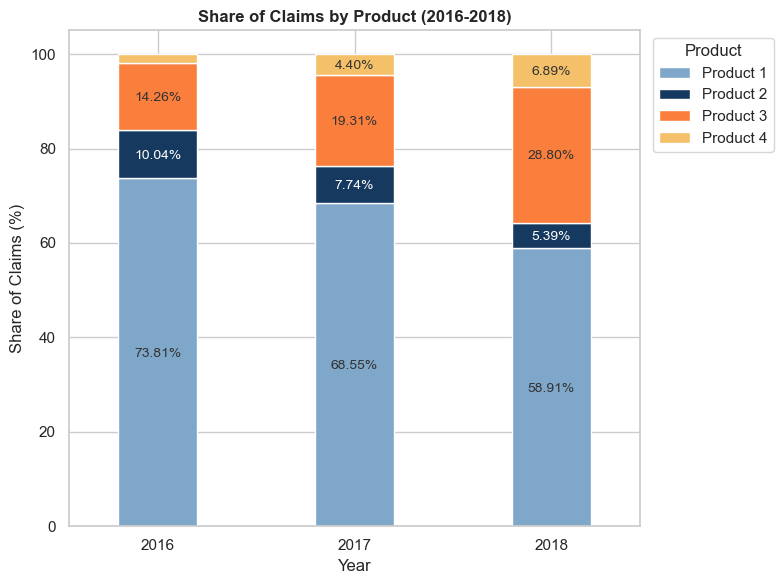

In [49]:
# data viz for 1.a.1.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
claims_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

# add percentage labels
for product in claims_pct.columns:
    for i, year in enumerate(claims_pct.index):
        value = claims_pct.loc[year, product]

        if value < 3:
            continue

        bottom = claims_pct.loc[year, claims_pct.columns[:claims_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2

        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{value:.2f}%', ha='center', va='center_baseline', fontsize=10, color=text_color)

ax.set_title('Share of Claims by Product (2016-2018)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Claims (%)')
ax.set_xticklabels(claims_pct.index, rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [50]:
# 1.a.2.
# 100% stacked bar graph showing the number of patients of each product per year
patients_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['Patient_ID']
    .nunique()
    .unstack(['Product_Name'])[product_order]
)
patients_pivot['Total'] = patients_pivot.sum(axis=1)

patients_pivot


Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,2017,395,544,81,3037
2017,2155,398,862,229,3644
2018,2021,283,1266,367,3937


In [51]:
patients_pct = round(patients_pivot[product_order].div(patients_pivot['Total'], axis=0) * 100, 2)

patients_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,66.41,13.01,17.91,2.67
2017,59.14,10.92,23.66,6.28
2018,51.33,7.19,32.16,9.32


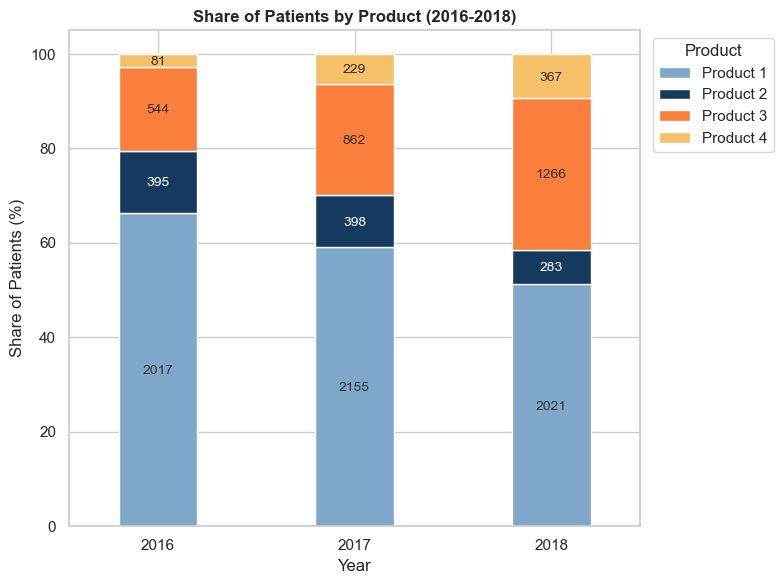

In [52]:
# data viz for 1.a.2.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
patients_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

# add percentage labels
for product in patients_pct.columns:
    for i, year in enumerate(patients_pct.index):
        value = patients_pct.loc[year, product]
        bottom = patients_pct.loc[year, patients_pct.columns[:patients_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2
        count = int(patients_pivot.loc[year, product])

        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{count}', ha='center', va='center_baseline', fontsize=10, color=text_color)

ax.set_title('Share of Patients by Product (2016-2018)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Patients (%)')
ax.set_xticklabels(patients_pct.index, rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [53]:
# 1.a.3.
# 100% stacked bar graph showing the number of HCPs (I.e., writers) writing claims for each product per year
hcp_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['HCP_ID']
    .nunique()
    .unstack(['Product_Name'])[product_order]
  )
hcp_pivot['Total'] = hcp_pivot.sum(axis=1)

hcp_pivot

Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,492,285,344,72,1193
2017,495,276,416,187,1374
2018,496,226,468,268,1458


In [54]:
hcp_pct = round(hcp_pivot[product_order].div(hcp_pivot['Total'], axis=0) * 100, 2)

hcp_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,41.24,23.89,28.83,6.04
2017,36.03,20.09,30.28,13.61
2018,34.02,15.50,32.10,18.38


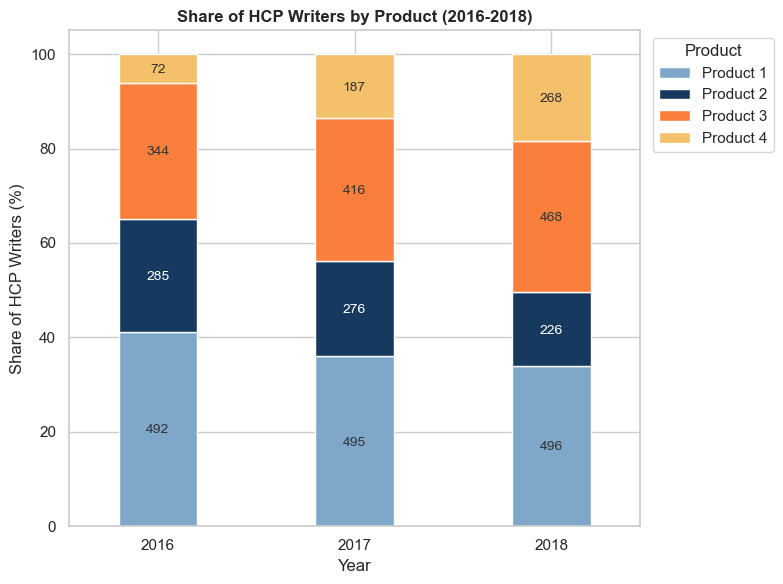

In [55]:
# data viz for 1.a.3.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
hcp_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

for product in hcp_pct.columns:
    for i, year in enumerate(hcp_pct.index):
        value = hcp_pct.loc[year, product]
        bottom = hcp_pct.loc[year, hcp_pct.columns[:hcp_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2
        count = int(hcp_pivot.loc[year, product])
        
        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{count}', ha='center', va='center_baseline', fontsize=10, color=text_color)

ax.set_title('Share of HCP Writers by Product (2016-2018)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of HCP Writers (%)')
ax.set_xticklabels(hcp_pct.index, rotation=0)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 1.a.4. Observations & Actionable Recommendations

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of Claims</strong></span><br>
<strong>Observation</strong>: Product 3 is the primary beneficiary of Product 1's declining market leadership, capturing 28.80% of total claims in 2018, up from 14.26% in 2016, while Product 2 contracted from 10.04% to 5.39% over the same period. Notably, the overall market expanded from 4,272 to 5,600 annual claims, confirming that Product 2's erosion is driven by competitive displacement rather than market contraction.<br>

<strong>Recommendation</strong>: Realign sales force targeting toward Product 1 writers who are at risk of migration to Product 3. Given the growing market, converting even a fraction of Product 3's incremental share gain into Product 2 adoption would represent a meaningful recovery in competitive positioning.
<br><br>

<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of Patients</strong></span><br>
<strong>Observation</strong>: Product 3 nearly doubled its unique patient base from 544 (17.91%) in 2016 to 1,266 (32.16%) in 2018, while Product 2's patient reach declined from 395 to 283 over the same period. The divergence in patient volume trends suggests Product 3 is succeeding not only in new patient acquisition but also in patient retention, an area where Product 2 is underperforming.<br>

<strong>Recommendation</strong>: Implement structured patient retention initiatives, including copay support and treatment adherence programs, to reduce mid-treatment attrition from Product 2. Stabilizing the existing patient base is a prerequisite before any meaningful share recovery can be achieved.
<br><br>

<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of HCP Writers</strong></span><br>
<strong>Observation</strong>: The total HCP writer base in the injectable anesthesia market grew from 1,193 in 2016 to 1,458 in 2018, indicating active market expansion. However, Product 2 failed to benefit from this growth: its writer count declined from 285 to 226, while Product 3 added 124 net new writers over the same period. This pattern suggests that newly entering HCPs are disproportionately initiating with Product 3, further entrenching its competitive advantage.<br>

<strong>Recommendation</strong>: Prioritize early engagement with HCPs new to the injectable anesthesia segment before brand preference is established. Field force efforts should be supplemented with medical education and peer-to-peer programs to establish Product 2's clinical differentiation at the point of prescriber onboarding.
</div>

### **2. Identifying the trends of the Key Market Drivers of the Injectable Anesthesia Market**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
You got to know from the Primary market research team that the Patient Age, Specialty of the patient diagnosis, HCP Specialty and New prescriber growth are the key Market Drivers of the Injectable anesthetics. Investigate these metrics and their trends. How could you leverage the trends of these key market drivers to increase your market share for Product 2? How could these trends relate to the competitor brand's growth (Product 3) and your Variant brand's decline (Product 2)?
</div>

### **3. Strategies to stop the market share erosion and gain traction in the market for the Variant Brand**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
You may convince your leadership to increase the budget and/or labor resources to gain market leadership. The analyses you have done so far should support the recommendations. What are the key business areas or metrics that require attention based on the metrics analyzed so far? Based on your observations, what are the strategic recommendations you would offer to the on-field sales force and promotional strategies. How can improvements be made to target specific customer segments, optimize the sales force, and enhance non-personal promotions? Your solution should include actionable steps to stop the eroding market share of the Variant Brand immediately as a priority.
</div>

### **4. Data Exploration Opportunities:**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
What are the analyses you would pursue out of the scope of the given Medicare claims data? Do you have any concerns with the data? If so, why, and what actionable steps would you take to resolve this while not losing sight of the primary goal of arresting the losing market erosion? What data gaps did you find in the given data and what other datasets can help you fill this and provide the data summaries you want for this case?
</div>